In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import math

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, InputLayer
from keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

from lightgbm import LGBMClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import yfinance as yf

import warnings
warnings.simplefilter(action='ignore', category=Warning)

2023-08-21 22:19:12.832670: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-08-21 22:19:12.855322: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-21 22:19:13.173800: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
#Download the data
market_indices = ['^GSPC','^N225','^GSPTSE','^AXJO','^GDAXI','^FTSE']
macroeconomics = ['^TNX','^VIX']
commodity_data = ['GC=F','CL=F','SI=F','NG=F','HG=F','ZW=F','ZC=F','PL=F','PA=F','KC=F']
FX_pairs = ['USDJPY=X','USDCAD=X','USDEUR=X','USDAUD=X','USDGBP=X']

#Time period
start_date="2012-01-01"
end_date="2023-06-30"

overall_data = yf.download(market_indices+macroeconomics+commodity_data+FX_pairs,start_date,end_date)["Adj Close"]
overall_data = overall_data.dropna()


[*********************100%***********************]  23 of 23 completed


In [3]:
# Define different technical indicators
def EMA(df, n):
    EMA = pd.Series(df.ewm(span=n, min_periods=n).mean(), name='EMA_' + str(n))
    return EMA

def ROC(df, n):
    M = df.diff(n - 1)
    N = df.shift(n - 1)
    ROC = pd.Series(((M / N) * 100), name = 'ROC_' + str(n))
    return ROC

def MOM(df, n):
    MOM = pd.Series(df.diff(n), name='Momentum_' + str(n))
    return MOM

def RSI(series, period):
    delta = series.diff().dropna()
    u = delta * 0
    d = u.copy()
    u[delta > 0] = delta[delta > 0]
    d[delta < 0] = -delta[delta < 0]
    u[u.index[period-1]] = np.mean( u[:period] ) #first value is sum of avg gains
    u = u.drop(u.index[:(period-1)])
    d[d.index[period-1]] = np.mean( d[:period] ) #first value is sum of avg losses
    d = d.drop(d.index[:(period-1)])
    rs = u.ewm(com=period-1, adjust=False).mean() / \
    d.ewm(com=period-1, adjust=False).mean()
    return 100 - 100 / (1 + rs)


In [4]:
def check_algos(X_train, Y_train, num_folds=5, scoring='accuracy', seed=7):
    # spot check the algorithms
    models = []
    models.append(('LR', LogisticRegression(n_jobs=-1, max_iter=10000, penalty='l1', solver='liblinear')))
    models.append(('LDA', LinearDiscriminantAnalysis()))
    #models.append(('KNN', KNeighborsClassifier()))
    models.append(('CART', DecisionTreeClassifier()))
    models.append(('NB', GaussianNB()))
    #Neural Network
    models.append(('NN', MLPClassifier(max_iter=1000)))
    #Ensable Models
    # Boosting methods
    models.append(('AB', AdaBoostClassifier()))
    #models.append(('GBM', GradientBoostingClassifier()))
    models.append(('LGBM', LGBMClassifier()))
    # Bagging methods
    models.append(('RF', RandomForestClassifier(n_jobs=-1)))

    results = []
    names = []
    for name, model in models:
        kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)

    # compare algorithms
    fig = plt.figure()
    fig.suptitle('Algorithm Comparison ' + predict_daily_pair)
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    fig.set_size_inches(15,8)
    plt.show()

def eval_model(model, X_validation, Y_validation):
    # estimate accuracy on validation set
    predictions = model.predict(X_validation)

    print(accuracy_score(Y_validation, predictions))
    print(confusion_matrix(Y_validation, predictions))
    print(classification_report(Y_validation, predictions))

    df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 16})# font sizes
    plt.suptitle(predict_daily_pair)
    plt.show()

    try:
        Importance = pd.DataFrame({'Importance':model.feature_importances_*100}, index=X_validation.columns)
        Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r' )
        plt.xlabel('Variable Importance')
        plt.suptitle(predict_daily_pair)
        plt.show()
        return
    except:
        
        return


In [5]:
import optuna
from sklearn.model_selection import cross_val_score
def best_RF(X_train, Y_train):      #RF performed the best in general
    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 20, 200)
        max_depth = trial.suggest_int('max_depth', 1, 500)
        criterion = trial.suggest_categorical('criterion', ['gini','entropy'])
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion)
        return cross_val_score(clf, X_train, Y_train, n_jobs=-1, cv=5).mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)
    
    #Print Results
    print("Best: %f using %s" % (study.best_trial.value, study.best_trial.params))
    return RandomForestClassifier(**study.best_trial.params, n_jobs=-1)


In [6]:
def backtest(model, X_backtest, change):
    action = model.predict(X_backtest) * 2 - 1
    print(f'Profit: {sum(action * change)}')
    print(f'Buy & Hold 1 USD:{sum(change)}')
    return

In [7]:
all_columns = overall_data.columns
indicators = pd.DataFrame()

for col in all_columns:
    indicators['EMA5_'+col] = EMA(overall_data[col], 5)
    indicators['EMA20_'+col] = EMA(overall_data[col], 20)
    indicators['EMA50_'+col] = EMA(overall_data[col], 50)

    #calculation of rate of change

    indicators['ROC10_'+col] = ROC(overall_data[col], 10)
    indicators['ROC30_'+col] = ROC(overall_data[col], 30)

    #Calculation of price momentum

    indicators['MOM10_'+col] = MOM(overall_data[col], 10)
    indicators['MOM30_'+col] = MOM(overall_data[col], 30)

    #calculation of relative strength index

    indicators['RSI5_'+col] = RSI(overall_data[col], 5)
    indicators['RSI20_'+col] = RSI(overall_data[col], 20)
    indicators['RSI50_'+col] = RSI(overall_data[col], 50)


In [8]:

X = pd.concat([overall_data[:-1].pct_change()[1:],indicators[1:]], axis=1)[51:-1]


In [9]:
X_backtest = X.loc[X.index >= '2023-01-01']
X = X.loc[X.index < '2023-01-01']


USDJPY=X

LR: 0.690733 (0.024579)
LDA: 0.701214 (0.022998)
CART: 0.593911 (0.036512)
NB: 0.646252 (0.008898)
NN: 0.609637 (0.024146)
AB: 0.688128 (0.008424)
LGBM: 0.698055 (0.025673)
RF: 0.706430 (0.026367)


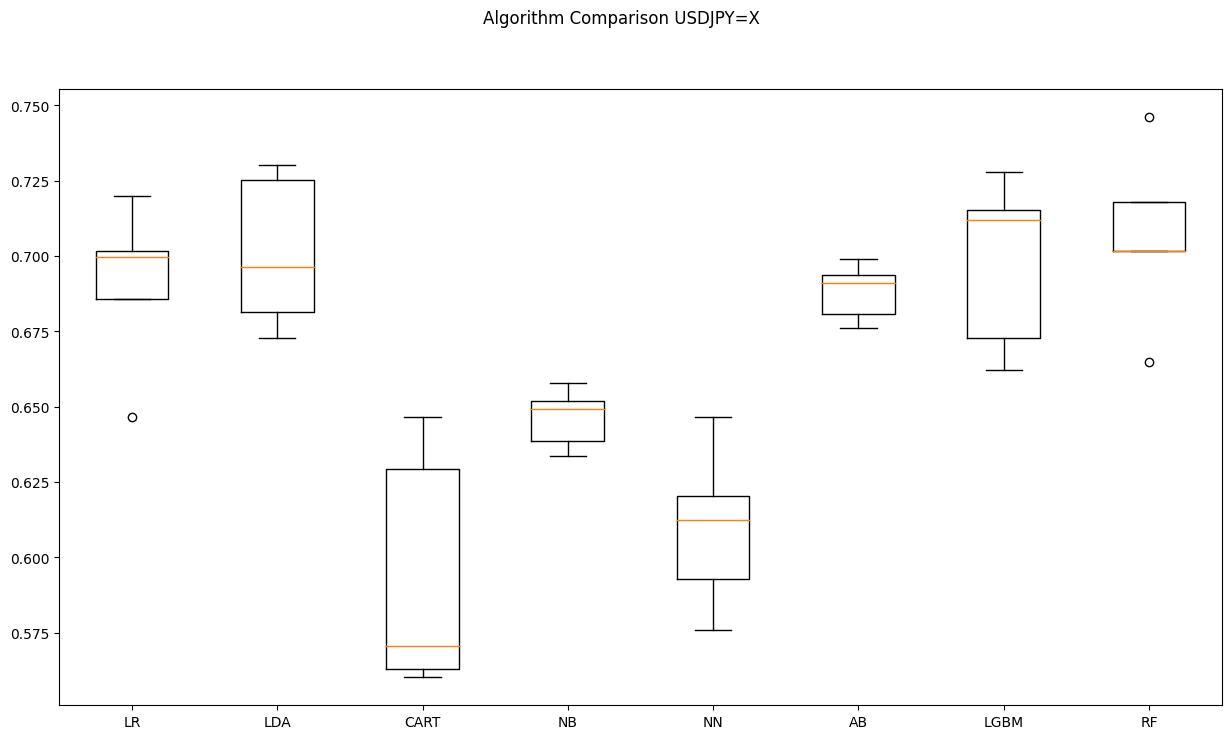

[I 2023-08-21 22:19:46,089] A new study created in memory with name: no-name-98f0e839-e076-41d2-9e68-e7d9c4c1c6ff
[I 2023-08-21 22:19:46,988] Trial 0 finished with value: 0.7006821319699809 and parameters: {'n_estimators': 65, 'max_depth': 238, 'criterion': 'gini'}. Best is trial 0 with value: 0.7006821319699809.
[I 2023-08-21 22:19:47,802] Trial 1 finished with value: 0.6954547318633548 and parameters: {'n_estimators': 128, 'max_depth': 393, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7006821319699809.
[I 2023-08-21 22:19:48,475] Trial 2 finished with value: 0.697550339698987 and parameters: {'n_estimators': 101, 'max_depth': 199, 'criterion': 'gini'}. Best is trial 0 with value: 0.7006821319699809.
[I 2023-08-21 22:19:48,894] Trial 3 finished with value: 0.6912553142044755 and parameters: {'n_estimators': 35, 'max_depth': 445, 'criterion': 'gini'}. Best is trial 0 with value: 0.7006821319699809.
[I 2023-08-21 22:19:49,396] Trial 4 finished with value: 0.699122387325195 and

Best: 0.711680 using {'n_estimators': 118, 'max_depth': 403, 'criterion': 'entropy'}
0.6548117154811716
[[145  79]
 [ 86 168]]
              precision    recall  f1-score   support

           0       0.63      0.65      0.64       224
           1       0.68      0.66      0.67       254

    accuracy                           0.65       478
   macro avg       0.65      0.65      0.65       478
weighted avg       0.66      0.65      0.66       478



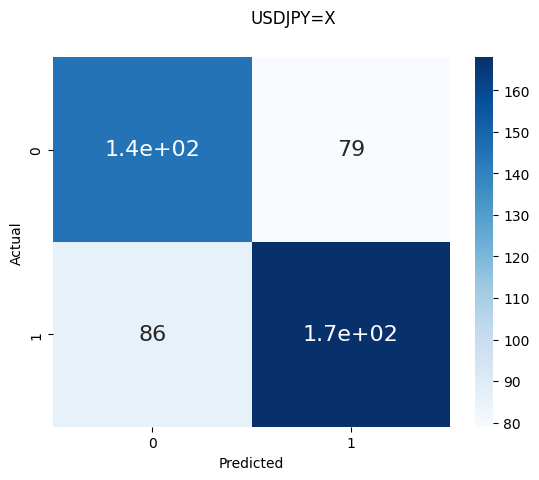

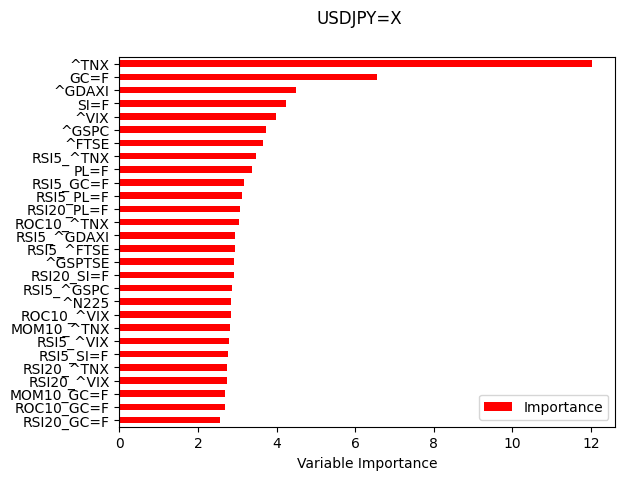

Profit: 51.26692199707031
Buy & Hold 1 USD:13.141006469726562
Mean cost :134.79843195643994

USDCAD=X

LR: 0.672396 (0.026888)
LDA: 0.672402 (0.028762)
CART: 0.601781 (0.007895)
NB: 0.612240 (0.019496)
NN: 0.585556 (0.011688)
AB: 0.667176 (0.021238)
LGBM: 0.689681 (0.013636)
RF: 0.681826 (0.020275)


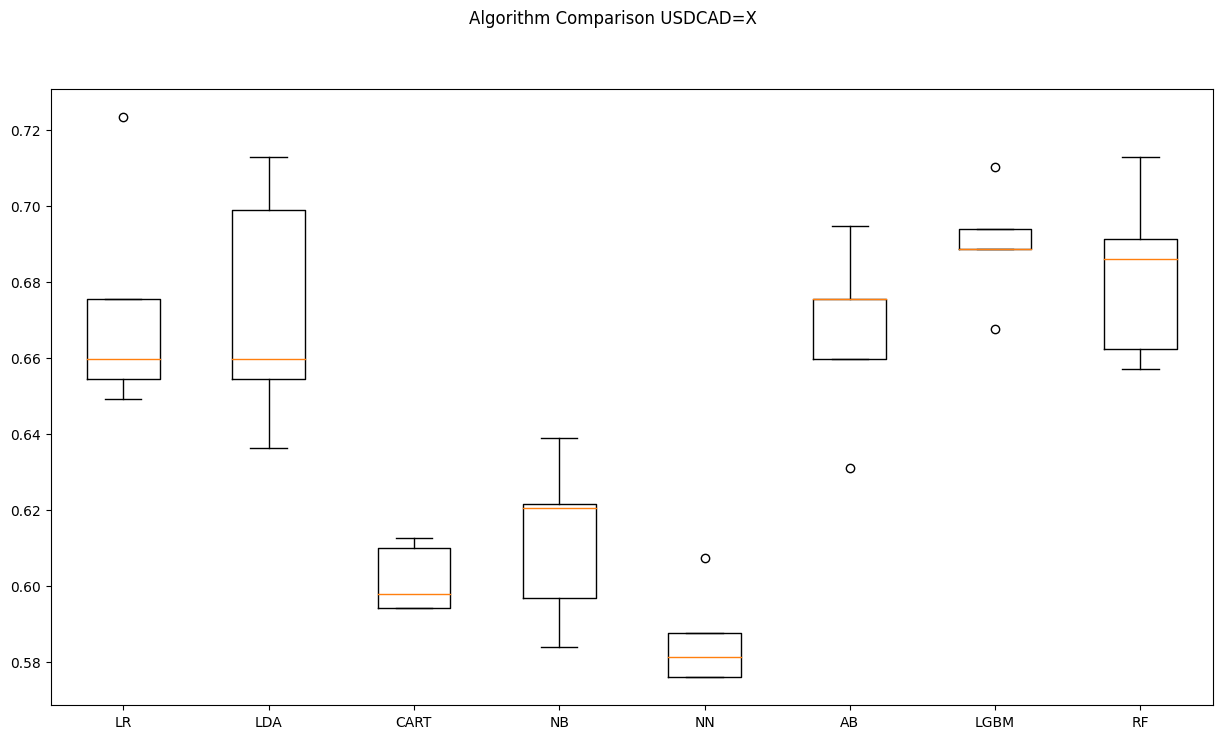

[I 2023-08-21 22:20:53,458] A new study created in memory with name: no-name-e76c0727-5950-458e-bcd6-d8d1fd4db515
[I 2023-08-21 22:20:53,966] Trial 0 finished with value: 0.6923215725944254 and parameters: {'n_estimators': 116, 'max_depth': 343, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6923215725944254.
[I 2023-08-21 22:20:54,300] Trial 1 finished with value: 0.6865514743072737 and parameters: {'n_estimators': 78, 'max_depth': 140, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6923215725944254.
[I 2023-08-21 22:20:54,637] Trial 2 finished with value: 0.7027791068035487 and parameters: {'n_estimators': 79, 'max_depth': 475, 'criterion': 'entropy'}. Best is trial 2 with value: 0.7027791068035487.
[I 2023-08-21 22:20:55,092] Trial 3 finished with value: 0.6964963842904597 and parameters: {'n_estimators': 106, 'max_depth': 189, 'criterion': 'entropy'}. Best is trial 2 with value: 0.7027791068035487.
[I 2023-08-21 22:20:55,286] Trial 4 finished with value: 0.692835563

Best: 0.702779 using {'n_estimators': 79, 'max_depth': 475, 'criterion': 'entropy'}
0.6715481171548117
[[155  87]
 [ 70 166]]
              precision    recall  f1-score   support

           0       0.69      0.64      0.66       242
           1       0.66      0.70      0.68       236

    accuracy                           0.67       478
   macro avg       0.67      0.67      0.67       478
weighted avg       0.67      0.67      0.67       478



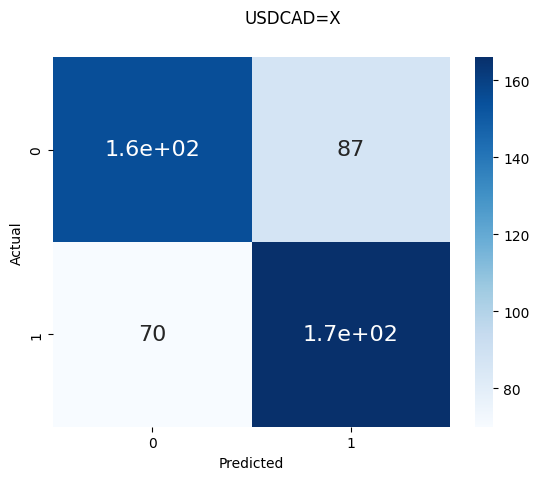

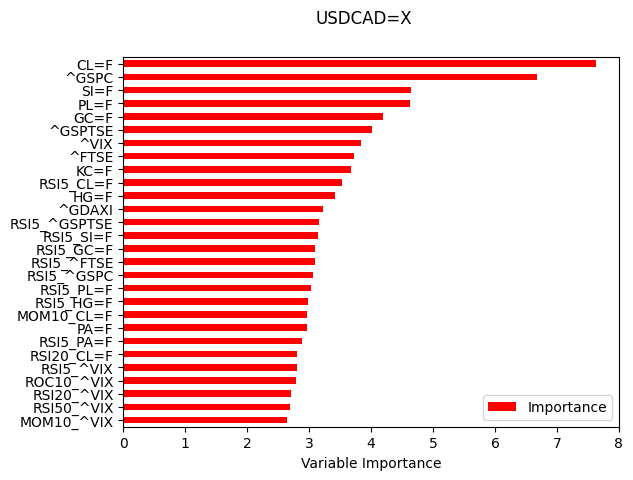

Profit: 0.2046506404876709
Buy & Hold 1 USD:-0.04222989082336426
Mean cost :1.3474422037054639

USDEUR=X

LR: 0.608575 (0.021357)
LDA: 0.619563 (0.028563)
CART: 0.541080 (0.033604)
NB: 0.590781 (0.015634)
NN: 0.541088 (0.013148)
AB: 0.582936 (0.013456)
LGBM: 0.615388 (0.013129)
RF: 0.610164 (0.021226)


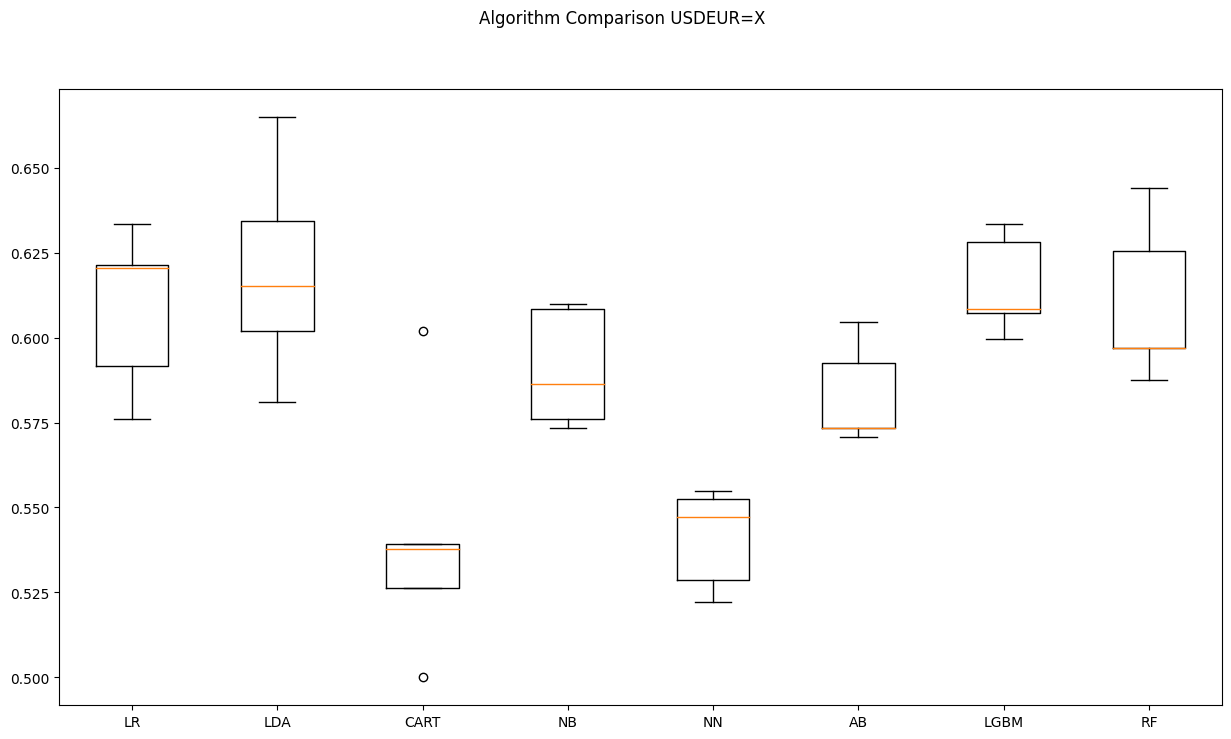

[I 2023-08-21 22:21:57,656] A new study created in memory with name: no-name-a11bb3a7-78e5-465a-8f17-48be27a9f058
[I 2023-08-21 22:21:57,901] Trial 0 finished with value: 0.6091028392547128 and parameters: {'n_estimators': 50, 'max_depth': 159, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6091028392547128.
[I 2023-08-21 22:21:58,044] Trial 1 finished with value: 0.6085751780514811 and parameters: {'n_estimators': 34, 'max_depth': 460, 'criterion': 'gini'}. Best is trial 0 with value: 0.6091028392547128.
[I 2023-08-21 22:21:58,713] Trial 2 finished with value: 0.622699000724509 and parameters: {'n_estimators': 168, 'max_depth': 297, 'criterion': 'gini'}. Best is trial 2 with value: 0.622699000724509.
[I 2023-08-21 22:21:59,201] Trial 3 finished with value: 0.6227044687162522 and parameters: {'n_estimators': 109, 'max_depth': 386, 'criterion': 'entropy'}. Best is trial 3 with value: 0.6227044687162522.
[I 2023-08-21 22:21:59,780] Trial 4 finished with value: 0.6216600822932759 

Best: 0.635269 using {'n_estimators': 145, 'max_depth': 392, 'criterion': 'entropy'}
0.5899581589958159
[[132 121]
 [ 75 150]]
              precision    recall  f1-score   support

           0       0.64      0.52      0.57       253
           1       0.55      0.67      0.60       225

    accuracy                           0.59       478
   macro avg       0.60      0.59      0.59       478
weighted avg       0.60      0.59      0.59       478



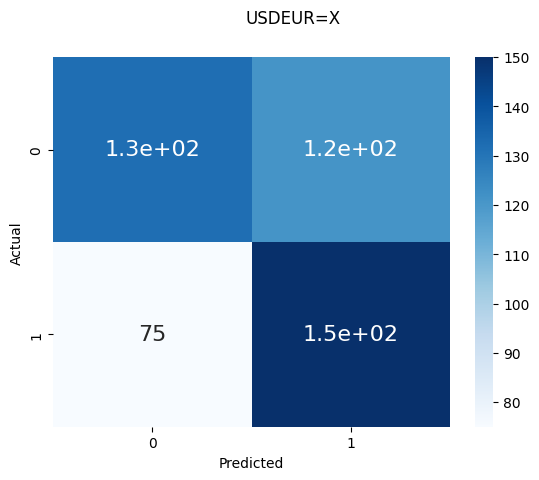

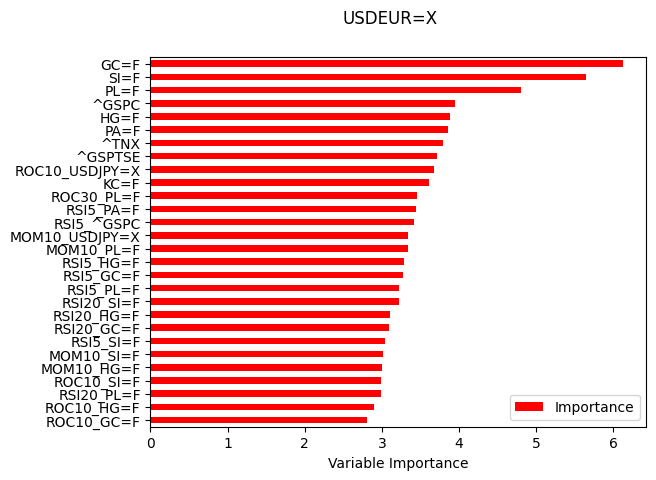

Profit: 0.17574995756149292
Buy & Hold 1 USD:-0.03204995393753052
Mean cost :0.9257722032179526

USDAUD=X

LR: 0.657233 (0.014068)
LDA: 0.672406 (0.017987)
CART: 0.586069 (0.014402)
NB: 0.594954 (0.028542)
NN: 0.575598 (0.016985)
AB: 0.652527 (0.017908)
LGBM: 0.646784 (0.010899)
RF: 0.656699 (0.025044)


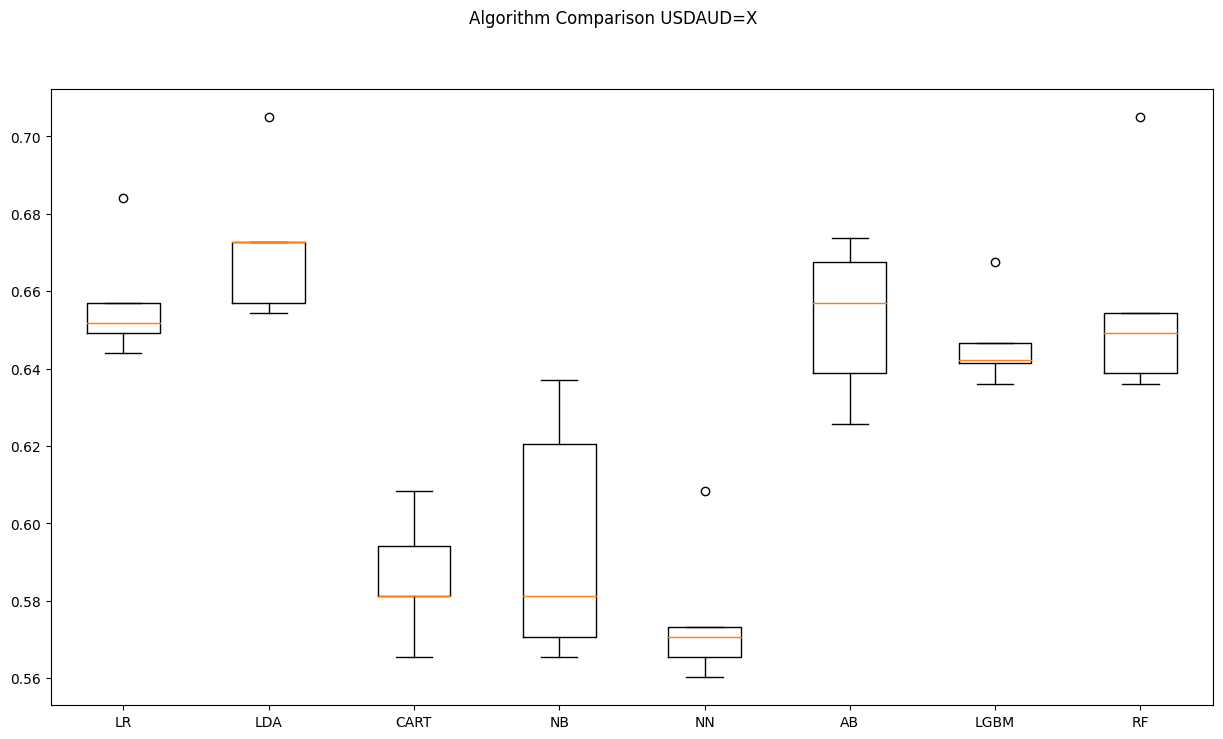

[I 2023-08-21 22:23:20,903] A new study created in memory with name: no-name-bc635558-9430-4645-9393-4b05c69b62e0
[I 2023-08-21 22:23:21,502] Trial 0 finished with value: 0.6666712233264528 and parameters: {'n_estimators': 146, 'max_depth': 23, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6666712233264528.
[I 2023-08-21 22:23:21,939] Trial 1 finished with value: 0.6619632824354436 and parameters: {'n_estimators': 113, 'max_depth': 392, 'criterion': 'gini'}. Best is trial 0 with value: 0.6666712233264528.
[I 2023-08-21 22:23:22,124] Trial 2 finished with value: 0.6724153486528235 and parameters: {'n_estimators': 46, 'max_depth': 108, 'criterion': 'gini'}. Best is trial 2 with value: 0.6724153486528235.
[I 2023-08-21 22:23:22,562] Trial 3 finished with value: 0.6718999904310144 and parameters: {'n_estimators': 112, 'max_depth': 359, 'criterion': 'gini'}. Best is trial 2 with value: 0.6724153486528235.
[I 2023-08-21 22:23:22,896] Trial 4 finished with value: 0.6682391699588534 a

Best: 0.682900 using {'n_estimators': 104, 'max_depth': 363, 'criterion': 'entropy'}
0.6443514644351465
[[152  86]
 [ 84 156]]
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       238
           1       0.64      0.65      0.65       240

    accuracy                           0.64       478
   macro avg       0.64      0.64      0.64       478
weighted avg       0.64      0.64      0.64       478



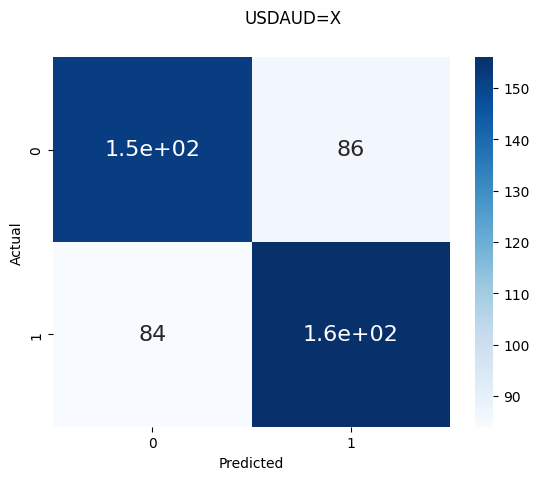

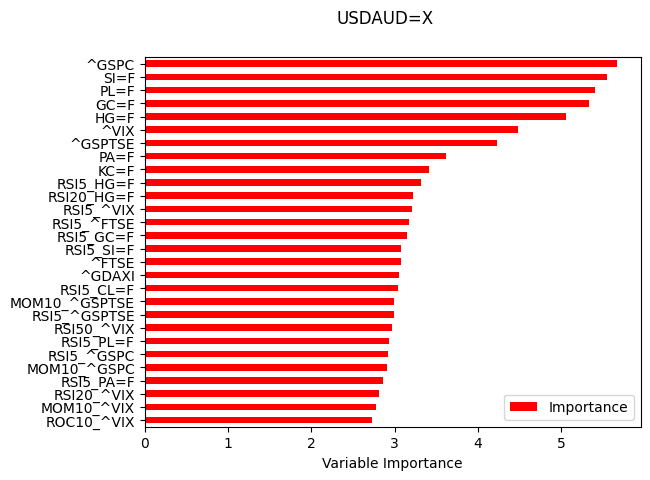

Profit: 0.6014472246170044
Buy & Hold 1 USD:0.028684020042419434
Mean cost :1.4791385919675915

USDGBP=X

LR: 0.595492 (0.024267)
LDA: 0.611183 (0.021297)
CART: 0.544747 (0.023978)
NB: 0.602808 (0.022767)
NN: 0.545809 (0.028222)
AB: 0.592885 (0.010869)
LGBM: 0.588177 (0.016355)
RF: 0.602297 (0.033055)


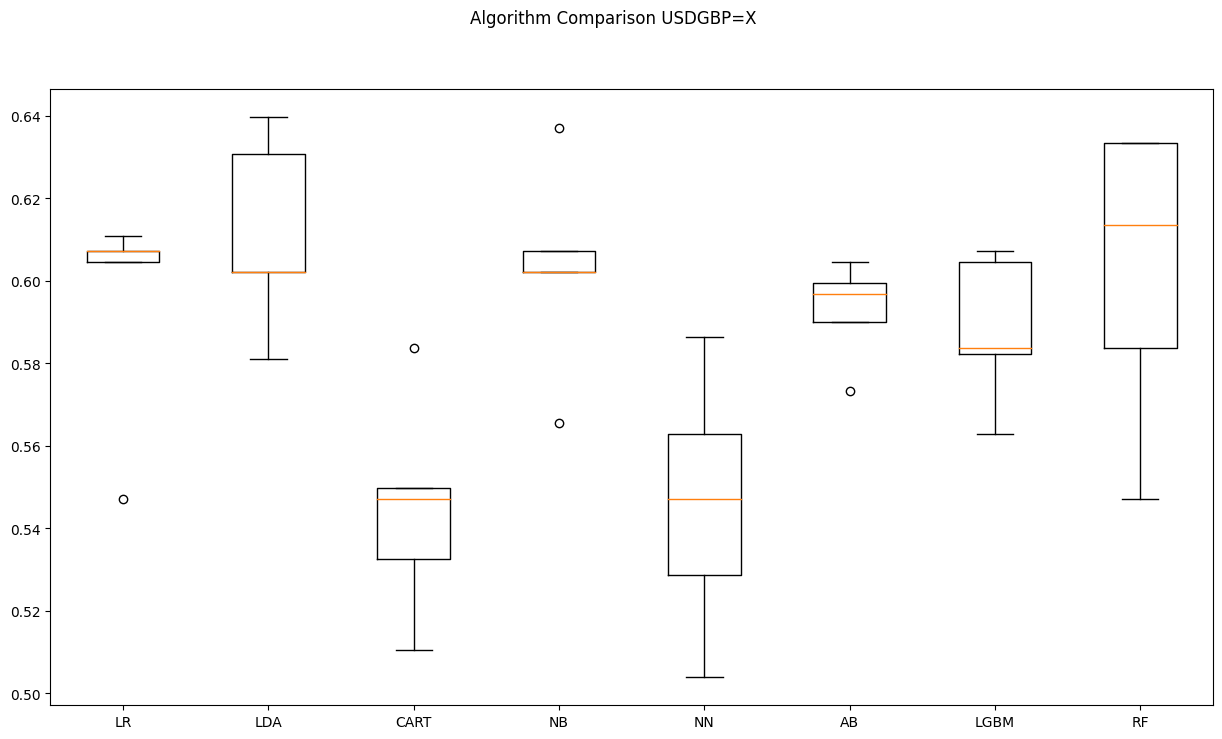

[I 2023-08-21 22:24:41,410] A new study created in memory with name: no-name-0d18cddd-f9d7-46c5-b572-a02f333dcff4
[I 2023-08-21 22:24:41,748] Trial 0 finished with value: 0.6002091506841826 and parameters: {'n_estimators': 83, 'max_depth': 139, 'criterion': 'gini'}. Best is trial 0 with value: 0.6002091506841826.
[I 2023-08-21 22:24:42,293] Trial 1 finished with value: 0.6012576381009664 and parameters: {'n_estimators': 118, 'max_depth': 203, 'criterion': 'entropy'}. Best is trial 1 with value: 0.6012576381009664.
[I 2023-08-21 22:24:42,671] Trial 2 finished with value: 0.61119024510273 and parameters: {'n_estimators': 95, 'max_depth': 440, 'criterion': 'gini'}. Best is trial 2 with value: 0.61119024510273.
[I 2023-08-21 22:24:43,420] Trial 3 finished with value: 0.6033450439489837 and parameters: {'n_estimators': 189, 'max_depth': 283, 'criterion': 'gini'}. Best is trial 2 with value: 0.61119024510273.
[I 2023-08-21 22:24:43,604] Trial 4 finished with value: 0.6033477779448553 and par

Best: 0.621135 using {'n_estimators': 105, 'max_depth': 343, 'criterion': 'entropy'}
0.5627615062761506
[[123 109]
 [100 146]]
              precision    recall  f1-score   support

           0       0.55      0.53      0.54       232
           1       0.57      0.59      0.58       246

    accuracy                           0.56       478
   macro avg       0.56      0.56      0.56       478
weighted avg       0.56      0.56      0.56       478



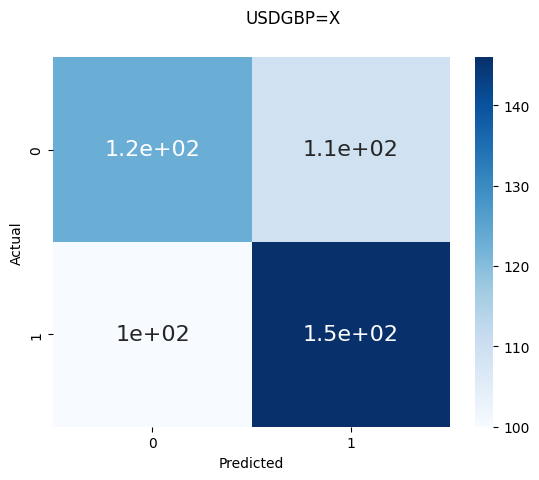

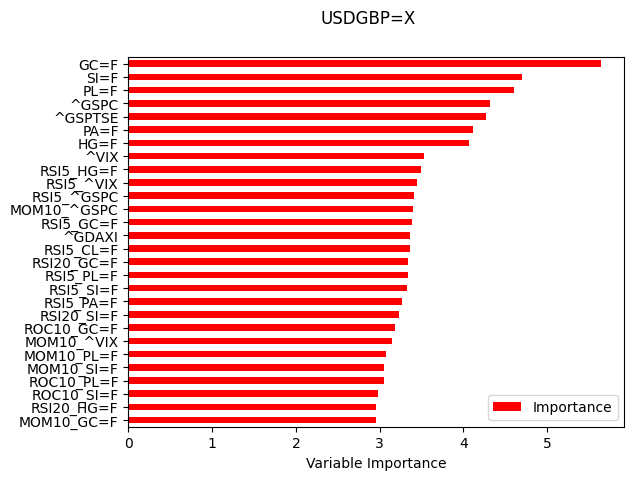

Profit: 0.15434831380844116
Buy & Hold 1 USD:-0.0444599986076355
Mean cost :0.8116089439173357


In [10]:
for predict_daily_pair in FX_pairs:
    print('\n'+predict_daily_pair+'\n')
    y = ((np.sign(np.sign(overall_data[predict_daily_pair].diff(1).shift(-1)[1:-1])-0.1)+1)//2).astype(int)[51:]
    y_final = y.loc[y.index < '2023-01-01']

    selected = abs(pd.concat([X,y_final],axis=1).corr().iloc[:,-1]).sort_values()[-30+1:].index[:-1]  # select top 30 correlated (or negatively correlated) predictors
    X_final = X[selected]

    X_train, X_validation, Y_train, Y_validation = train_test_split(X_final, y_final, test_size=0.2, random_state=1)

    check_algos(X_train, Y_train)

    model = best_RF(X_train, Y_train)
    model.fit(X_train, Y_train)

    eval_model(model, X_validation, Y_validation)

    overall_data[predict_daily_pair].loc[overall_data.index >= '2023-01-01']

    fx_change = overall_data[predict_daily_pair].diff(1).shift(-1)[1:-1]
    backtest(model, X_backtest[selected], fx_change.loc[fx_change.index >= '2023-01-01'])
    print(f"Mean cost :{overall_data[predict_daily_pair].loc[overall_data.index >= '2023-01-01'].mean()}")


